In [66]:
%load_ext autoreload
%autoreload 2

import argparse
import warnings
from dataclasses import dataclass
from pathlib import Path

import hist
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.optimize import OptimizeWarning, curve_fit
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
from tqdm import tqdm
from uncertainties import ufloat
from uncertainties import unumpy as unp

from analysis.gravnet.model import NeutrinoGravNetNodesFaser
from analysis.utils.colors import TangoColors
from analysis.utils.datasets import CNNProjectionDataset
from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.models import GraphClassifier, MuonHitNetClassifier
from analysis.utils.plot_utils import setup
from analysis.utils.torch_geometric_utils import evaluate_gravnet_model_nodes
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

# Suppress uncertainties deprecation warning
warnings.filterwarnings("ignore", message=".*unumpy_to_numpy_matrix.*")
warnings.filterwarnings("ignore", message=".*AffineScalarFun*")
warnings.filterwarnings("ignore", message=".*OptimizeWarning*")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def linear_fct(x: np.ndarray, c0: float, c1: float) -> np.ndarray:
    """Linear function for fitting."""
    return c0 + c1 * x


def weighted_mean_std(values: np.ndarray, weights: np.ndarray) -> tuple[float, float]:
    """Calculate weighted mean and standard deviation."""
    average = np.average(values, weights=weights)
    variance = np.average((values - average) ** 2, weights=weights)
    return average, np.sqrt(variance)


def gaussian_2d_simple(
    xy: tuple[np.ndarray, np.ndarray],
    amplitude: float,
    x_mean: float,
    x_std: float,
    y_mean: float,
    y_sigma: float,
    offset: float,
) -> float:
    """2D Gaussian function for fitting."""
    x, y = xy
    return (
        amplitude
        * np.exp(
            -(
                (x - x_mean) ** 2 / (2 * x_std**2 + 1e-6)
                + (y - y_mean) ** 2 / (2 * y_sigma**2 + 1e-6)
            )
        )
        + offset
    )


def fit_2d(
    xcenters: np.ndarray, ycenters: np.ndarray, h, initial_guess: tuple
) -> tuple:
    """Fit 2D Gaussian to histogram data."""

    X, Y = np.meshgrid(xcenters, ycenters, indexing="ij")
    Z = h.values()

    x_data = X.flatten()
    y_data = Y.flatten()
    z_data = Z.flatten()

    # Catch OptimizeWarning when covariance cannot be estimated
    with warnings.catch_warnings():
        warnings.filterwarnings("error", category=OptimizeWarning)
        try:
            popt, pcov = curve_fit(
                gaussian_2d_simple,
                (x_data, y_data),
                z_data,
                p0=initial_guess,
                maxfev=10000,
            )
            perr = np.sqrt(np.diag(pcov))
        except (OptimizeWarning, RuntimeError):
            # If covariance cannot be estimated or fit fails, set uncertainties to -1
            popt, _ = curve_fit(
                gaussian_2d_simple,
                (x_data, y_data),
                z_data,
                p0=initial_guess,
                maxfev=10000,
                check_finite=False,
            )
            perr = np.full_like(popt, -1.0)  # Set all uncertainties to -1

    return tuple(unp.uarray(popt, perr))


In [10]:
def get_center_layers(
    pos_df: pd.DataFrame,
    layer_offset: int = 5,
    num_layers: int = 8,
    fit_range: float = 4,
    plot: bool = True,
    truth_pos: np.ndarray | None = None,
):
    layer_query = "idx >= @layer_offset & idx <= @layer_offset + 5"
    xcenter, ycenter = pos_df.query(layer_query)[["x", "y"]].mean()

    xbins = np.arange(xcenter - fit_range, xcenter + fit_range, 0.2)
    ybins = np.arange(ycenter - fit_range, ycenter + fit_range, 0.2)

    xcenters = 0.5 * (xbins[1:] + xbins[:-1])
    ycenters = 0.5 * (ybins[1:] + ybins[:-1])

    h = hist.Hist(hist.axis.Variable(xbins), hist.axis.Variable(ybins))

    layer_x_pos = []
    layer_y_pos = []
    # layer_x_unc = []
    # layer_y_unc = []
    layer_z_pos = []

    num_rows = 2
    num_cols = num_layers // num_rows
    if plot:
        fig, axs = plt.subplots(
            num_rows, num_cols, figsize=(6 * num_cols, 6 * num_rows)
        )

    for i in range(num_layers):
        layer_idx = layer_offset + i
        layer_df = pos_df.query("idx == @layer_idx")

        h.fill(layer_df["x"], layer_df["y"])

        try:
            xmean, xstd = weighted_mean_std(xcenters, weights=h.values().sum(axis=1))
            ymean, ystd = weighted_mean_std(ycenters, weights=h.values().sum(axis=0))
            initial_guess = (10, xmean, 0.5 * xstd, ymean, 0.5 * ystd, 1)

            # 2D fit
            x_n, x_mean, x_std, y_mean, y_std, offset = fit_2d(
                xcenters, ycenters, h, initial_guess
            )
            layer_x_pos.append(x_mean)
            layer_y_pos.append(y_mean)
            # layer_x_unc.append(x_std)
            # layer_y_unc.append(y_std)
            layer_z_pos.append(layer_idx)

            if plot:
                ax = axs.flatten()[i]
                mplhep.hist2dplot(
                    h, cmap="viridis", cbar=False, cmin=0.1, ax=ax, flow=None
                )
                ax.errorbar(
                    x_mean.n,
                    y_mean.n,
                    xerr=np.abs(x_std.n),
                    yerr=np.abs(y_std.n),
                    color="orange",
                    marker="o",
                    markersize=8,
                    label="Fit",
                )
                if truth_pos is not None:
                    ax.scatter(
                        truth_pos[0],
                        truth_pos[1],
                        color="red",
                        marker="x",
                        s=100,
                        label="Truth",
                    )
                ax.set_title(f"Layer {layer_idx}")
                ax.set_xlabel("x [mm]")
                ax.set_ylabel("y [mm]")
                ax.legend()
        except Exception:
            xm, ym = layer_df[["x", "y"]].mean()
            xs, ys = layer_df[["x", "y"]].std()

            layer_x_pos.append(ufloat(xm, xs))
            layer_y_pos.append(ufloat(ym, ys))
            # layer_x_unc.append(ufloat(xs, xs * 0.5))
            # layer_y_unc.append(ufloat(ys, ys * 0.5))
            layer_z_pos.append(layer_idx - layer_offset)
    if plot:
        plt.tight_layout()
        plt.show()

    return np.array(layer_x_pos), np.array(layer_y_pos), np.array(layer_z_pos)


def get_center_vertex(
    xpos: np.ndarray,
    ypos: np.ndarray,
    zpos: np.ndarray,
    offset: int = 5,
    plot: bool = False,
    truth_pos: np.ndarray | None = None,
):
    x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err = 0, 0, 0, 0, 0, 0, 0, 0
    if (len(xpos) != len(ypos)) or (len(xpos) != len(zpos)):
        raise ValueError("Input arrays must have the same length.")
    if len(xpos) == 0:
        return x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err
    if len(xpos) < 2:
        x0 = np.mean(unp.nominal_values(xpos))
        y0 = np.mean(unp.nominal_values(ypos))
        x0_std = np.std(unp.nominal_values(xpos))
        y0_std = np.std(unp.nominal_values(ypos))
        return x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err

    x_nominal = unp.nominal_values(xpos)
    x_std_dev = unp.std_devs(xpos)

    try:
        # Extract nominal values and uncertainties to avoid deprecation warning
        x_nominal = unp.nominal_values(xpos)
        x_std_dev = unp.std_devs(xpos)
        y_nominal = unp.nominal_values(ypos)
        y_std_dev = unp.std_devs(ypos)

        # Fit X position vs layer ID
        xpopt, xpcov = curve_fit(
            linear_fct,
            zpos,
            x_nominal,
            sigma=x_std_dev,
            absolute_sigma=True,
        )
        xperr = np.sqrt(np.diag(xpcov))
        # Extrapolate to layer 0
        x0_fit = linear_fct(
            offset, ufloat(xpopt[0], xperr[0]), ufloat(xpopt[1], xperr[1])
        )
        dx_dz = float(xpopt[1])  # Slope
        dx_dz_err = float(xperr[1])  # Slope uncertainty

        # Fit Y position vs layer ID
        ypopt, ypcov = curve_fit(
            linear_fct,
            zpos,
            y_nominal,
            sigma=y_std_dev,
            absolute_sigma=True,
        )
        yperr = np.sqrt(np.diag(ypcov))
        # Extrapolate to layer 0
        y0_fit = linear_fct(
            offset, ufloat(ypopt[0], yperr[0]), ufloat(ypopt[1], yperr[1])
        )
        dy_dz = float(ypopt[1])  # Slope
        dy_dz_err = float(yperr[1])  # Slope uncertainty

        # Extract nominal values and uncertainties
        x0 = x0_fit.n
        y0 = y0_fit.n
        x0_std = x0_fit.s
        y0_std = y0_fit.s

    except Exception:
        # If linear fit fails, fall back to mean of positions
        x0 = np.mean(unp.nominal_values(xpos))
        y0 = np.mean(unp.nominal_values(ypos))
        x0_std = np.std(unp.nominal_values(xpos))
        y0_std = np.std(unp.nominal_values(ypos))
        dx_dz = 0.0
        dy_dz = 0.0
        dx_dz_err = 0.0
        dy_dz_err = 0.0
        return x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err

    if plot:
        fig, axs = plt.subplots(1, 2, figsize=(2 * 6, 4))
        axs[0].errorbar(
            zpos,
            y=unp.nominal_values(xpos),
            yerr=unp.std_devs(xpos),
            ls="",
            marker="o",
        )
        axs[0].scatter(
            offset,
            truth_pos[0],
            color="red",
            marker="x",
            s=100,
            label="Truth",
        )
        axs[0].plot(
            zpos,
            linear_fct(zpos, *xpopt),
            color=TangoColors.orange,
            ls="--",
            label="Fit",
        )
        axs[0].errorbar(offset, x0, yerr=x0_std, color=TangoColors.sky_blue)
        axs[0].set_xlabel("Layer")
        axs[0].set_ylabel("$x$ [mm]")

        axs[1].errorbar(
            zpos,
            y=unp.nominal_values(ypos),
            yerr=unp.std_devs(ypos),
            color=TangoColors.sky_blue,
            marker="o",
            ls="",
        )
        axs[1].scatter(
            offset,
            truth_pos[1],
            color="red",
            marker="x",
            s=100,
            label="Truth",
        )
        axs[1].plot(
            zpos,
            linear_fct(zpos, *ypopt),
            ls="--",
            color=TangoColors.orange,
            label="Fit",
        )
        axs[1].set_xlabel("Layer")
        axs[1].set_ylabel("$y$ [mm]")
        axs[1].legend()

        plt.tight_layout()
        plt.show()

    return x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err


def get_shower_vertex(
    pos_df: pd.DataFrame,
    layer_offset: int = 5,
    num_layers: int = 8,
    fit_range: float = 4,
    plot: bool = True,
    truth_pos: np.ndarray | None = None,
):
    xpos, ypos, zpos = get_center_layers(
        pos_df=pos_df,
        layer_offset=layer_offset,
        num_layers=num_layers,
        fit_range=fit_range,
        plot=plot,
        truth_pos=truth_pos,
    )
    return get_center_vertex(
        xpos=xpos,
        ypos=ypos,
        zpos=zpos,
        offset=layer_offset,
        plot=plot,
        truth_pos=truth_pos,
    )

In [4]:
setup()

In [5]:
@dataclass
class HitType:
    idx: int
    label: str
    latex_name: str
    color: str = "black"


other_hit = HitType(0, "other", "Other", TangoColors.sky_blue)
e_hit = HitType(1, "e", r"$e^{\pm}$", TangoColors.scarlet_red)
mu_hit = HitType(2, "mu", r"$\mu^{\pm}$", TangoColors.chameleon)
# hits = [other_hit, other_e_hit, primary_e_hit, primary_mu_hit]
hits = [other_hit, e_hit, mu_hit]

# Main


In [162]:
model = "gravnet_nodes_faser"
weights_path = get_weights_path() / f"{model}/best_model.pt"
figures_path = get_figures_path() / model
figures_path.mkdir(parents=True, exist_ok=True)

In [ ]:
# run = 10001
# chunk = 0
# run_name = "num"
# torch_path = get_torch_path() / Path(f"{run}/pointnetpp_faser_all_events")
# dataset = torch.load(torch_path / f"{run_name}_{chunk:03d}.pt")
# truth_df = pd.read_parquet(torch_path / f"{run_name}_{chunk:03d}_truth.parq")
# means = np.load(torch_path / f"{run_name}_{chunk:03d}_means.npy")

In [171]:
run = 10001
run_name = "num"
torch_path = get_torch_path() / Path(f"{run}/pointnetpp_faser_good_events")
dataset = torch.load(torch_path / f"{run_name}.pt")
truth_df = pd.read_parquet(torch_path / f"{run_name}_truth.parq")
means = np.load(torch_path / f"{run_name}_means.npy")

In [172]:
x0_lst, y0_lst, x0_std_lst, y0_std_lst = [], [], [], []
dx_dz_lst, dy_dz_lst, dx_dz_err_lst, dy_dz_err_lst = [], [], [], []
x_truth_lst, y_truth_lst = [], []

num_events = len(truth_df)
for event_idx in range(len(dataset)):
    z_bins = np.arange(5, 1505 + 1e-3, 10)
    pos_df = pd.DataFrame(
        dataset[event_idx].pos.numpy() * 100 + means[event_idx],
        columns=["x", "y", "z"],
    )
    pos_df["idx"] = pd.cut(pos_df["z"], bins=z_bins, labels=False)
    truth_pos = truth_df.iloc[event_idx][["vx", "vy", "vz"]].values

    x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err = get_shower_vertex(
        pos_df=pos_df,
        layer_offset=5,
        num_layers=8,
        fit_range=4,
        plot=False,
        truth_pos=truth_pos,
    )

    x_truth_lst.append(truth_pos[0])
    y_truth_lst.append(truth_pos[1])
    x0_lst.append(x0)
    y0_lst.append(y0)
    x0_std_lst.append(x0_std)
    y0_std_lst.append(y0_std)
    dx_dz_lst.append(dx_dz)
    dy_dz_lst.append(dy_dz)
    dx_dz_err_lst.append(dx_dz_err)
    dy_dz_err_lst.append(dy_dz_err)

KeyboardInterrupt: 

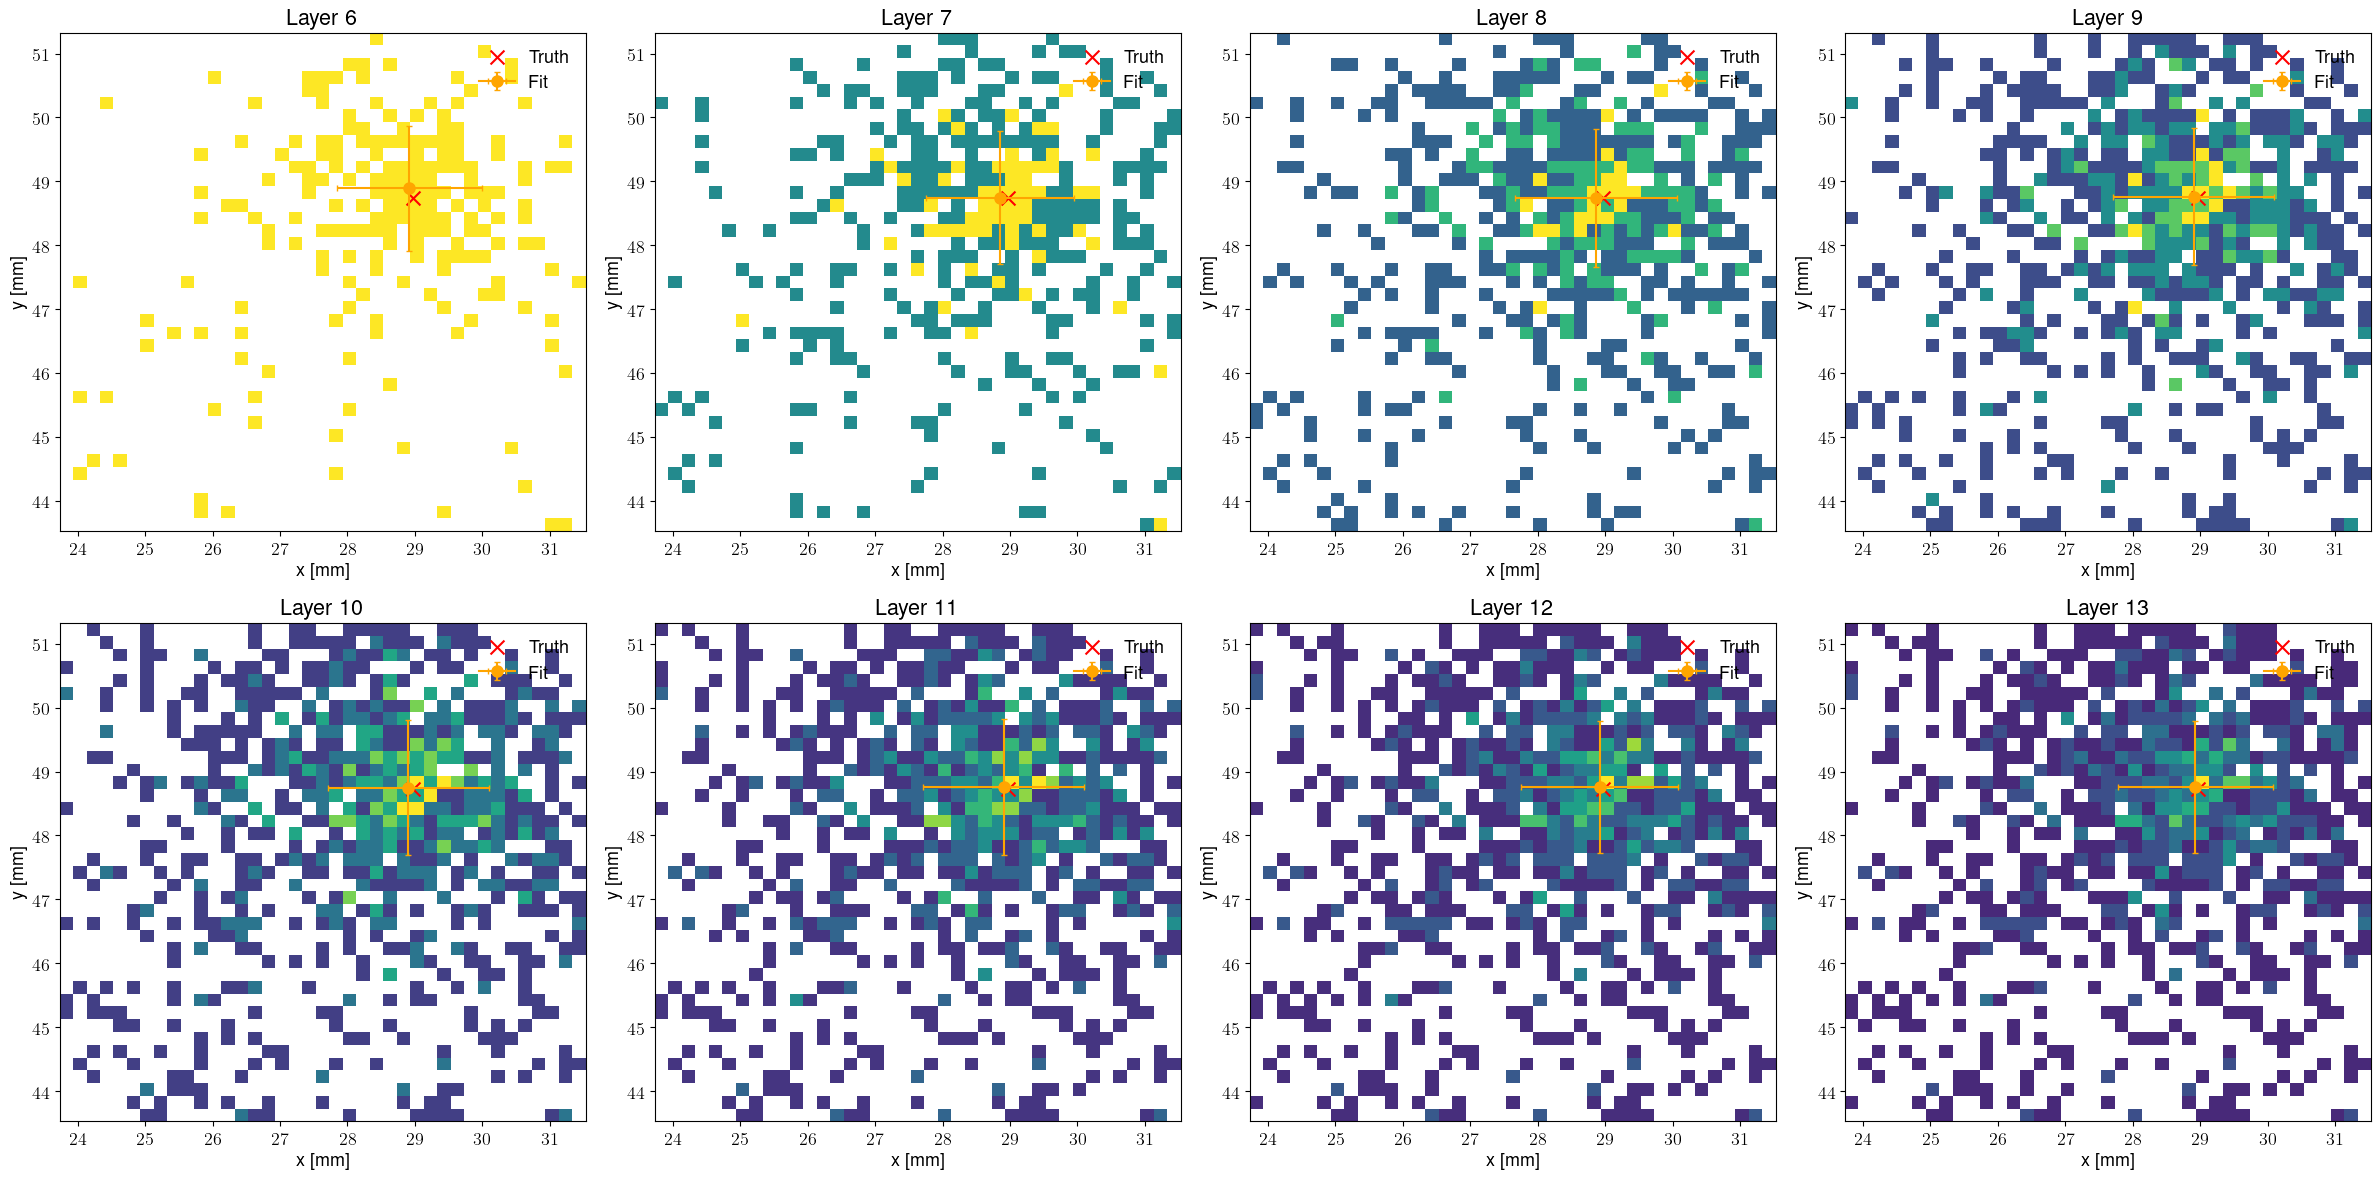

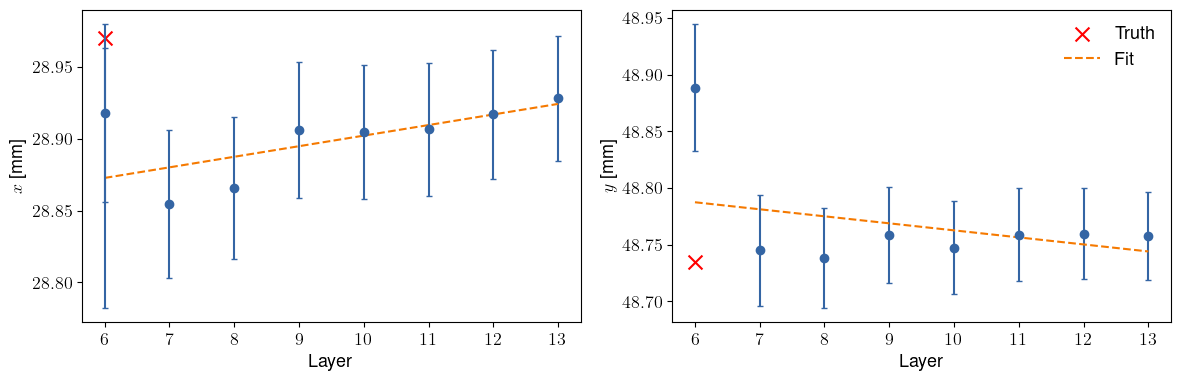

(28.872709921820825,
 48.78745663863152,
 0.0907211884338798,
 0.08256065316487908,
 0.007360253338219321,
 -0.006199920480302471,
 0.007705394044714997,
 0.006989971580672023)

In [69]:
event_idx = 0
z_bins = np.arange(5, 1505 + 1e-3, 10)
pos_df = pd.DataFrame(
    dataset[event_idx].pos.numpy() * 100 + means[event_idx],
    columns=["x", "y", "z"],
)
pos_df["idx"] = pd.cut(pos_df["z"], bins=z_bins, labels=False)
truth_pos = truth_df.iloc[event_idx][["vx", "vy", "vz"]].values

get_shower_vertex(
    pos_df=pos_df,
    layer_offset=6,
    num_layers=8,
    fit_range=4,
    plot=True,
    truth_pos=truth_pos,
)

In [62]:
def get_center_layers(
    pos_df: pd.DataFrame,
    layer_offset: int = 5,
    num_layers: int = 8,
    fit_range: float = 4,
    plot: bool = True,
    truth_pos: np.ndarray | None = None,
):
    layer_query = "idx >= @layer_offset & idx <= @layer_offset + 5"
    xcenter, ycenter = pos_df.query(layer_query)[["x", "y"]].mean()

    xbins = np.arange(xcenter - fit_range, xcenter + fit_range, 0.2)
    ybins = np.arange(ycenter - fit_range, ycenter + fit_range, 0.2)

    xcenters = 0.5 * (xbins[1:] + xbins[:-1])
    ycenters = 0.5 * (ybins[1:] + ybins[:-1])

    h = hist.Hist(hist.axis.Variable(xbins), hist.axis.Variable(ybins))

    layer_x_pos = []
    layer_y_pos = []
    # layer_x_unc = []
    # layer_y_unc = []
    layer_z_pos = []

    num_rows = 2
    num_cols = num_layers // num_rows
    if plot:
        fig, axs = plt.subplots(
            num_rows, num_cols, figsize=(6 * num_cols, 6 * num_rows)
        )

    for i in range(num_layers):
        layer_idx = layer_offset + i
        layer_df = pos_df.query("idx == @layer_idx")

        h.fill(layer_df["x"], layer_df["y"])

        try:
            xmean, xstd = weighted_mean_std(xcenters, weights=h.values().sum(axis=1))
            ymean, ystd = weighted_mean_std(ycenters, weights=h.values().sum(axis=0))
            initial_guess = (10, xmean, 0.5 * xstd, ymean, 0.5 * ystd, 1)

            # 2D fit
            x_n, x_mean, x_std, y_mean, y_std, offset = fit_2d(
                xcenters, ycenters, h, initial_guess
            )
            layer_x_pos.append(x_mean)
            layer_y_pos.append(y_mean)
            # layer_x_unc.append(x_std)
            # layer_y_unc.append(y_std)
            layer_z_pos.append(layer_idx)

            if plot:
                ax = axs.flatten()[i]
                mplhep.hist2dplot(
                    h, cmap="viridis", cbar=False, cmin=0.1, ax=ax, flow=None
                )
                ax.errorbar(
                    x_mean.n,
                    y_mean.n,
                    xerr=np.abs(x_std.n),
                    yerr=np.abs(y_std.n),
                    color="orange",
                    marker="o",
                    markersize=8,
                    label="Fit",
                )
                if truth_pos is not None:
                    ax.scatter(
                        truth_pos[0],
                        truth_pos[1],
                        color="red",
                        marker="x",
                        s=100,
                        label="Truth",
                    )
                ax.set_title(f"Layer {layer_idx}")
                ax.set_xlabel("x [mm]")
                ax.set_ylabel("y [mm]")
                ax.legend()
        except Exception:
            xm, ym = layer_df[["x", "y"]].mean()
            xs, ys = layer_df[["x", "y"]].std()

            layer_x_pos.append(ufloat(xm, xs))
            layer_y_pos.append(ufloat(ym, ys))
            # layer_x_unc.append(ufloat(xs, xs * 0.5))
            # layer_y_unc.append(ufloat(ys, ys * 0.5))
            layer_z_pos.append(layer_idx - layer_offset)
    if plot:
        plt.tight_layout()
        plt.show()

    return np.array(layer_x_pos), np.array(layer_y_pos), np.array(layer_z_pos)


def get_center_vertex(
    xpos: np.ndarray,
    ypos: np.ndarray,
    zpos: np.ndarray,
    offset: int = 5,
    plot: bool = False,
    truth_pos: np.ndarray | None = None,
):
    x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err = 0, 0, 0, 0, 0, 0, 0, 0
    if (len(xpos) != len(ypos)) or (len(xpos) != len(zpos)):
        raise ValueError("Input arrays must have the same length.")
    if len(xpos) == 0:
        return x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err
    if len(xpos) < 2:
        x0 = np.mean(unp.nominal_values(xpos))
        y0 = np.mean(unp.nominal_values(ypos))
        x0_std = np.std(unp.nominal_values(xpos))
        y0_std = np.std(unp.nominal_values(ypos))
        return x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err

    x_nominal = unp.nominal_values(xpos)
    x_std_dev = unp.std_devs(xpos)

    try:
        # Extract nominal values and uncertainties to avoid deprecation warning
        x_nominal = unp.nominal_values(xpos)
        x_std_dev = unp.std_devs(xpos)
        y_nominal = unp.nominal_values(ypos)
        y_std_dev = unp.std_devs(ypos)

        # Fit X position vs layer ID
        xpopt, xpcov = curve_fit(
            linear_fct,
            zpos,
            x_nominal,
            sigma=x_std_dev,
            absolute_sigma=True,
        )
        xperr = np.sqrt(np.diag(xpcov))
        # Extrapolate to layer 0
        x0_fit = linear_fct(
            offset, ufloat(xpopt[0], xperr[0]), ufloat(xpopt[1], xperr[1])
        )
        dx_dz = float(xpopt[1])  # Slope
        dx_dz_err = float(xperr[1])  # Slope uncertainty

        # Fit Y position vs layer ID
        ypopt, ypcov = curve_fit(
            linear_fct,
            zpos,
            y_nominal,
            sigma=y_std_dev,
            absolute_sigma=True,
        )
        yperr = np.sqrt(np.diag(ypcov))
        # Extrapolate to layer 0
        y0_fit = linear_fct(
            offset, ufloat(ypopt[0], yperr[0]), ufloat(ypopt[1], yperr[1])
        )
        dy_dz = float(ypopt[1])  # Slope
        dy_dz_err = float(yperr[1])  # Slope uncertainty

        # Extract nominal values and uncertainties
        x0 = x0_fit.n
        y0 = y0_fit.n
        x0_std = x0_fit.s
        y0_std = y0_fit.s

    except Exception:
        # If linear fit fails, fall back to mean of positions
        x0 = np.mean(unp.nominal_values(xpos))
        y0 = np.mean(unp.nominal_values(ypos))
        x0_std = np.std(unp.nominal_values(xpos))
        y0_std = np.std(unp.nominal_values(ypos))
        dx_dz = 0.0
        dy_dz = 0.0
        dx_dz_err = 0.0
        dy_dz_err = 0.0
        return x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err

    if plot:
        fig, axs = plt.subplots(1, 2, figsize=(2 * 6, 4))
        axs[0].errorbar(
            zpos,
            y=unp.nominal_values(xpos),
            yerr=unp.std_devs(xpos),
            ls="",
            marker="o",
        )
        axs[0].scatter(
            offset,
            truth_pos[0],
            color="red",
            marker="x",
            s=100,
            label="Truth",
        )
        axs[0].plot(
            zpos,
            linear_fct(zpos, *xpopt),
            color=TangoColors.orange,
            ls="--",
            label="Fit",
        )
        axs[0].errorbar(offset, x0, yerr=x0_std, color=TangoColors.sky_blue)
        axs[0].set_xlabel("Layer")
        axs[0].set_ylabel("$x$ [mm]")

        axs[1].errorbar(
            zpos,
            y=unp.nominal_values(ypos),
            yerr=unp.std_devs(ypos),
            color=TangoColors.sky_blue,
            marker="o",
            ls="",
        )
        axs[1].scatter(
            offset,
            truth_pos[1],
            color="red",
            marker="x",
            s=100,
            label="Truth",
        )
        axs[1].plot(
            zpos,
            linear_fct(zpos, *ypopt),
            ls="--",
            color=TangoColors.orange,
            label="Fit",
        )
        axs[1].set_xlabel("Layer")
        axs[1].set_ylabel("$y$ [mm]")
        axs[1].legend()

        plt.tight_layout()
        plt.show()

    return x0, y0, x0_std, y0_std, dx_dz, dy_dz, dx_dz_err, dy_dz_err


def get_shower_vertex(
    pos_df: pd.DataFrame,
    layer_offset: int = 5,
    num_layers: int = 8,
    fit_range: float = 4,
    plot: bool = True,
    truth_pos: np.ndarray | None = None,
):
    xpos, ypos, zpos = get_center_layers(
        pos_df=pos_df,
        layer_offset=layer_offset,
        num_layers=num_layers,
        fit_range=fit_range,
        plot=plot,
        truth_pos=truth_pos,
    )
    return get_center_vertex(
        xpos=xpos,
        ypos=ypos,
        zpos=zpos,
        offset=layer_offset,
        plot=plot,
        truth_pos=truth_pos,
    )

In [63]:
x_truth = np.array(x_truth_lst)
y_truth = np.array(y_truth_lst)
x0 = np.array(x0_lst)
y0 = np.array(y0_lst)
delta_x = x_truth - x0
delta_y = y_truth - y0

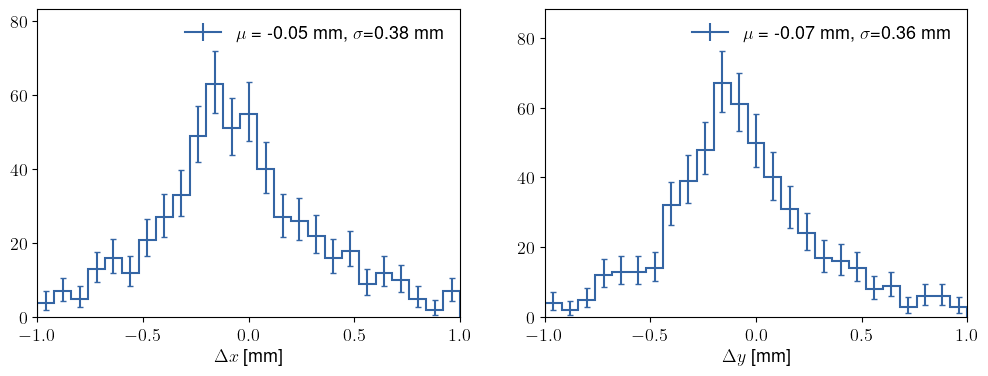

In [64]:
h = hist.Hist(hist.axis.Regular(25, -1, 1))
edges = h.axes[0].edges
centers = h.axes[0].centers

fig, axs = plt.subplots(1, 2, figsize=(2 * 6, 4))
for var, label, ax in zip([delta_x, delta_y], ["x", "y"], axs):
    h.reset()
    h.fill(var)
    mean, std = weighted_mean_std(centers, weights=h.values())
    mplhep.histplot(
        h, ax=ax, flow=None, label=rf"$\mu$ = {mean:.2f} mm, $\sigma$={std:.2f} mm"
    )
    ax.set_xlabel(rf"$\Delta {label}$ [mm]")
    ax.legend()
    ax.set_xlim(edges[0], edges[-1])
    ax.set_ylim(None, ax.get_ylim()[1] * 1.1)
plt.show()

In [173]:
device = get_device("cpu")

model = NeutrinoGravNetNodesFaser(
    input_dim=dataset[0].x.shape[1],
    num_node_classes=len(hits),
    faser_dim=dataset[0].x_faser.shape[0],
)
model = model.to(device)

load_weights(model, device=device, weights_path=weights_path)

Using device: cpu


In [174]:
def evaluate(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    use_faser: bool = False,
) -> tuple[list, list, list]:
    model.eval()
    all_targets, all_predictions, all_probabilities = [], [], []
    with torch.no_grad():
        for data in tqdm(test_loader, desc="Evaluating"):
            data = data.to(device)

            if data.x.size(0) == 0:
                continue

            if use_faser:
                out = model(data.x, data.pos, data.batch, data.x_faser)
            else:
                out = model(data.x, data.pos, data.batch)

            prob = torch.softmax(out, dim=1)
            pred = out.argmax(dim=1)

            all_targets.append(data.y.cpu().numpy())
            all_predictions.append(pred.cpu().numpy())
            all_probabilities.append(prob.cpu().numpy())

    return all_targets, all_predictions, all_probabilities

In [176]:
data_loader = DataLoader(dataset[:200])
# y_true, y_pred, y_prob = evaluate_gravnet_model_nodes(
y_true, y_pred, y_prob = evaluate(
    model=model,
    test_loader=data_loader,
    device=device,
    use_faser=True,
    # model=model, test_loader=test_loader, device=device
)
y_true_flat = np.concatenate(y_true)
y_pred_flat = np.concatenate(y_pred)
y_prob_flat = np.concatenate(y_prob)

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 200/200 [00:18<00:00, 11.05it/s]


In [177]:
class_names = ["Other", r"$\mu^{\pm}$"]

In [178]:
lookup = np.array([0, 0, 1])

yb_true = [lookup[arr] for arr in y_true]
yb_pred = [lookup[arr] for arr in y_pred]
yb_prob = [np.column_stack([arr[:, 0] + arr[:, 1], arr[:, 2]]) for arr in y_prob]

yb_true_flat = np.concatenate(yb_true)
yb_pred_flat = np.concatenate(yb_pred)
yb_prob_flat = np.concatenate(yb_prob)

2176017.0
2176017.0


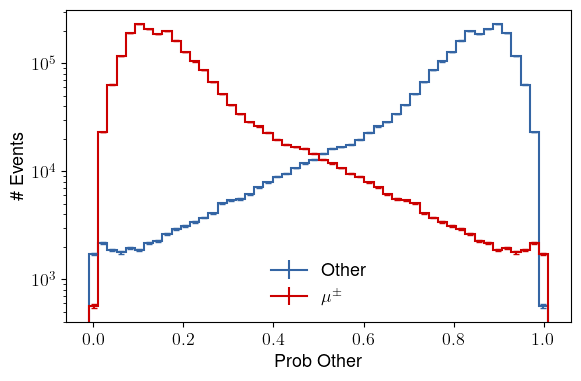

30304.0
30304.0


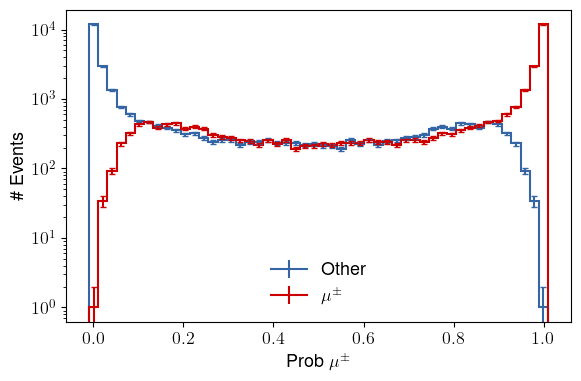

In [179]:
plot_probabilities(
    y_true=yb_true_flat,
    y_prob=yb_prob_flat,
    class_names=class_names,
    yscale="log",
)

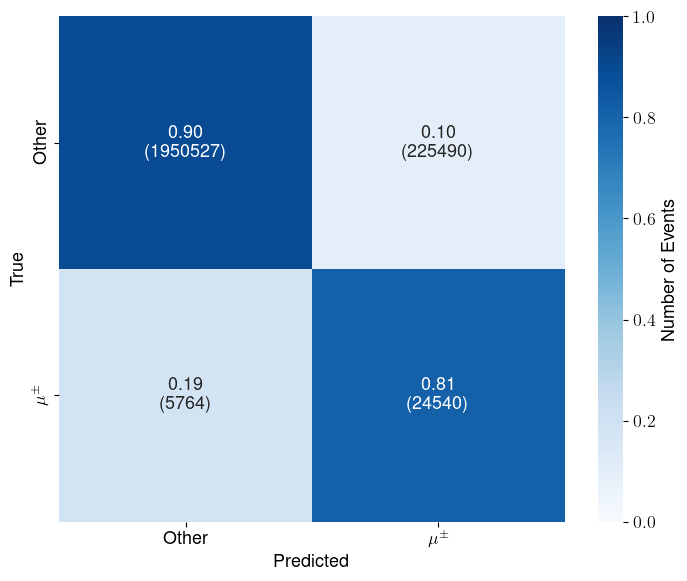

In [180]:
plot_confusion_matrix(
    yb_true_flat, yb_pred_flat, normalize=True, class_names=class_names
)

In [181]:
my_yb_pred = [yb_prob_evt[:, 1] > 0.99 for yb_prob_evt in yb_prob]
my_yb_pred_flat = np.concatenate(my_yb_pred)

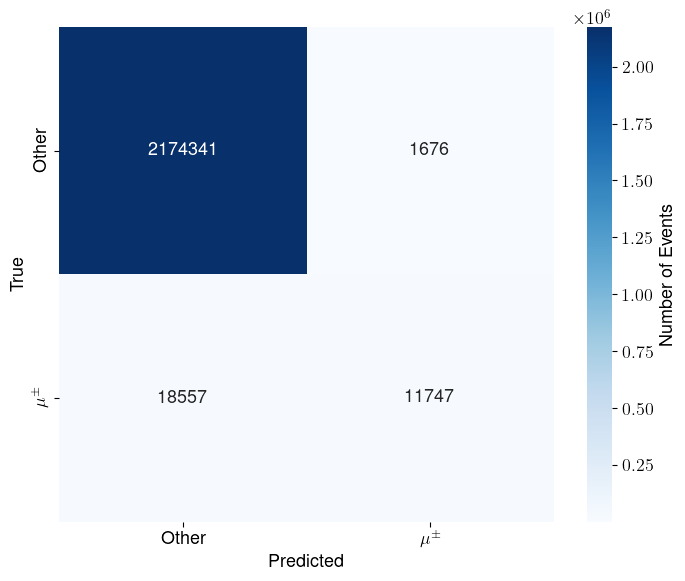

In [182]:
plot_confusion_matrix(
    yb_true_flat, my_yb_pred_flat, normalize=False, class_names=class_names
)

In [ ]:
for event_idx in range(5):
    print(event_idx)
    evt_hits_df = pd.DataFrame(
        deepcopy(test_data[event_idx].x),
        columns=["pixel_x", "pixel_y", "layer_id", "n_hits"],
    )
    evt_hits_df["pixel_x"] += x_centers[event_idx]
    evt_hits_df["pixel_y"] += y_centers[event_idx]
    truth = get_truth_particle(test_truth_df.iloc[event_idx])
    print("truth", truth.x, truth.y)
    size = 200

    # plot
    # zx_zy_hits_plots(truth, evt_hits_df, geo=geo, size=200 * 0.25)
    xlim = get_xlims(truth=truth, geo=geo, num_pixels=None, size=size)
    ylim = get_ylims(truth=truth, geo=geo, num_pixels=None, size=size)
    zlim = (0, int(geo.num_layers))

    # z_layers = np.linspace(0, 200, 200)
    # ax.plot(
    #     z_layers, track_params["x0"] + track_params["dx_dz"] * z_layers, color="red"
    # )
    # print(geo.get_x_pos(model_x.predict([[0]])), truth.x)

    x_center = geo.get_x_pixel(truth.x)
    y_center = geo.get_y_pixel(truth.y)
    query = (
        f"(pixel_x > {x_center} - {size // 2}) & (pixel_x < {x_center} + {size // 2})"
        f"& (pixel_y > {y_center} - {size // 2}) & (pixel_y < {y_center} + {size // 2})"
    )
    # true muon hits
    # muon_hits = evt_hits_df.loc[y_true[event_idy].astype(bool)]
    # if len(muon_hits.query(query)) == 0:
    #     continue
    # zx_zy_hits_plots(truth, muon_hits, geo=geo, size=size * 0.25)
    # predicted muon hits
    muon_hits = evt_hits_df.loc[y_pred[event_idx].astype(bool)]
    # if len(muon_hits.query(query)) == 0:
    #     continue

    # print("all")
    zlim = (0, 100)
    fig, axs = plt.subplots(1, 2, figsize=(2 * 6, 4))
    plot_zx_hits(
        df=evt_hits_df,
        # df=muon_hits,
        truth=truth,
        geo=geo,
        zlim=zlim,
        xlim=xlim,
        ax=axs[0],
        convert_to_mm=True,
    )
    plot_zy_hits(
        df=evt_hits_df,
        # df=muon_hits,
        truth=truth,
        geo=geo,
        zlim=zlim,
        ylim=ylim,
        ax=axs[1],
        convert_to_mm=True,
    )
    # zx_zy_hits_plots(truth, muon_hits, geo=geo, size=size * 0.25)
    mx, my, mdx, mdy, msx, msy = fit_muon_track(muon_hits, max_layer_id=150)
    mx2, my2, mdx2, mdy2, a, b, c = fit_muon_track_3d(muon_hits, max_layer_id=150)
    # print(a, b, c)

    z_layers = np.linspace(*zlim, 200)
    axs[0].plot(z_layers, mx + mdx * z_layers, color="red", alpha=0.2)
    axs[0].plot(z_layers, mx2 + mdx2 * z_layers, color="blue", alpha=0.2)
    axs[1].plot(z_layers, my + mdy * z_layers, color="red", alpha=0.2)
    axs[1].plot(z_layers, my2 + mdy2 * z_layers, color="blue", alpha=0.2)
    axs[0].set_xlim(*zlim)
    axs[1].set_xlim(*zlim)
    print(mx, geo.get_x_pos(mx), my, geo.get_y_pos(my))
    # print(mx, mdx, msx, len(muon_hits), msx / len(muon_hits))
    # print(my, mdy, msy, len(muon_hits), msy / len(muon_hits))
    plt.show()

    # print("muons")
    fig, axs = plt.subplots(1, 2, figsize=(2 * 6, 4))
    plot_zx_hits(
        # df=evt_hits_df,
        df=muon_hits,
        truth=truth,
        geo=geo,
        zlim=zlim,
        xlim=xlim,
        ax=axs[0],
        convert_to_mm=True,
    )
    plot_zy_hits(
        # df=evt_hits_df,
        df=muon_hits,
        truth=truth,
        geo=geo,
        zlim=zlim,
        ylim=ylim,
        ax=axs[1],
        convert_to_mm=True,
    )
    # zx_zy_hits_plots(truth, muon_hits, geo=geo, size=size * 0.25)
    # mx, my, mdx, mdy, msx, msy = fit_muon_track(muon_hits, max_layer_id=150)
    # mx2, my2, mdx2, mdy2, a, b, c = fit_muon_track_3d(muon_hits, max_layer_id=150)
    # print(a, b, c)

    z_layers = np.linspace(*zlim, 200)
    axs[0].plot(z_layers, mx + mdx * z_layers, color="red", alpha=0.2)
    axs[0].plot(z_layers, mx2 + mdx2 * z_layers, color="blue", alpha=0.2)
    axs[1].plot(z_layers, my + mdy * z_layers, color="red", alpha=0.2)
    axs[1].plot(z_layers, my2 + mdy2 * z_layers, color="blue", alpha=0.2)
    axs[0].set_xlim(*zlim)
    axs[1].set_xlim(*zlim)
    # print
    # print(mx, mdx, msx, len(muon_hits), msx / len(muon_hits))
    # print(my, mdy, msy, len(muon_hits), msy / len(muon_hits))
    plt.show()

In [86]:
my_flat_y_pred

array([False, False, False, ..., False, False, False], shape=(219129,))

In [85]:
acc_dict = get_accuracy_dict(
    y_true=y_true, y_pred=y_pred, class_names=[hit.label for hit in hits]
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

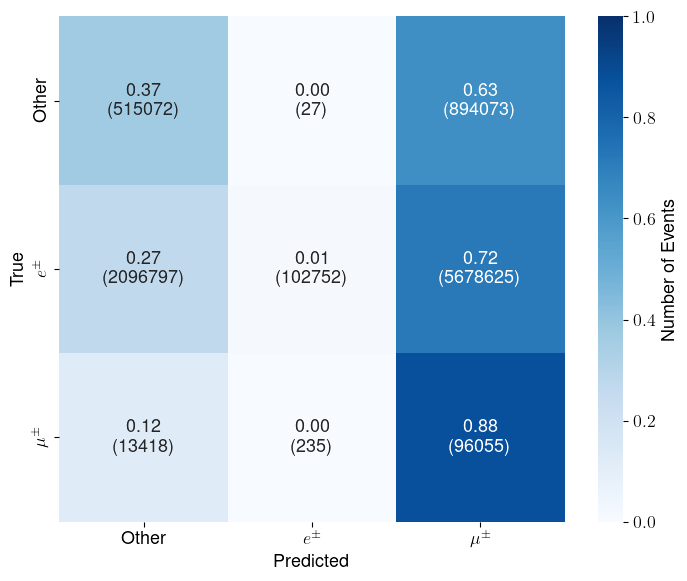

In [73]:
plot_confusion_matrix(
    y_true, y_pred, normalize=True, class_names=[hit.latex_name for hit in hits]
)

/Users/tboeckh/Documents/faser/neutrino-detector/analysis/src/analysis/utils/validation_utils.py:172: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/tboeckh/Library/Caches/pypoetry/virtualenvs/analysis-mEzhAUyO-py3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


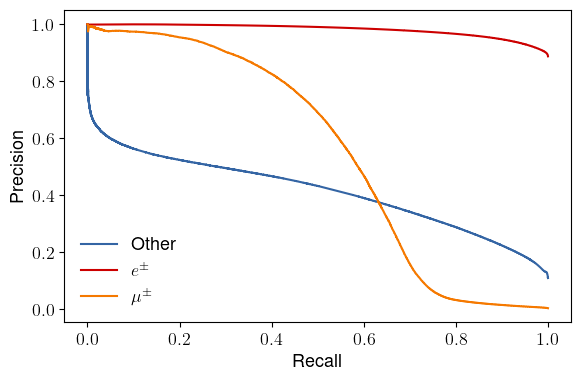

In [18]:
plot_precision_recall_curve(
    y_true=y_true, y_prob=y_prob, class_names=[hit.latex_name for hit in hits]
)

/Users/tboeckh/Documents/faser/neutrino-detector/analysis/src/analysis/utils/validation_utils.py:139: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/tboeckh/Library/Caches/pypoetry/virtualenvs/analysis-mEzhAUyO-py3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


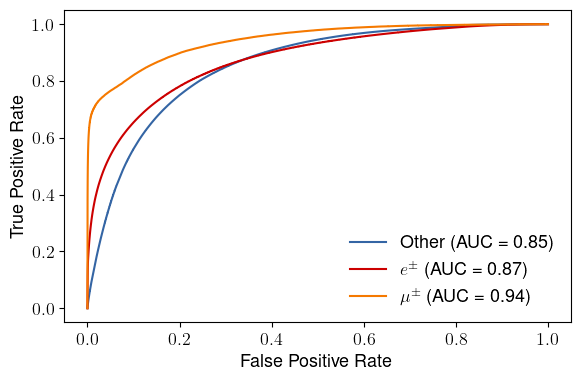

In [19]:
plot_roc_curve(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[hit.latex_name for hit in hits],
    figure_path=figures_path / "roc_curve.png",
)

2727820.0
2727820.0
2727820.0


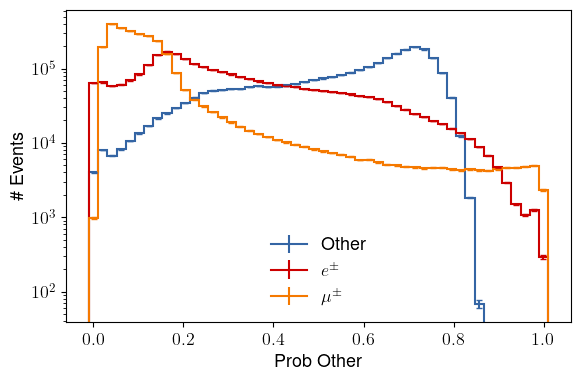

22139986.0
22139986.0
22139986.0


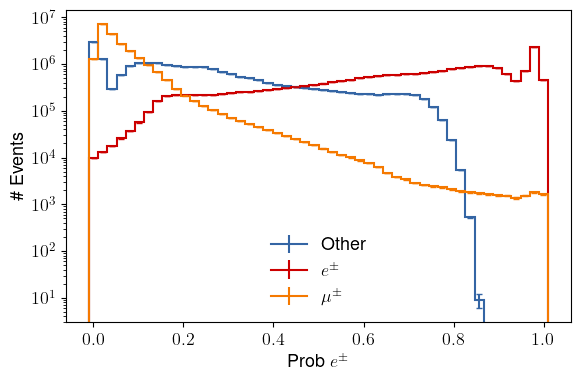

84706.0
84706.0
84706.0


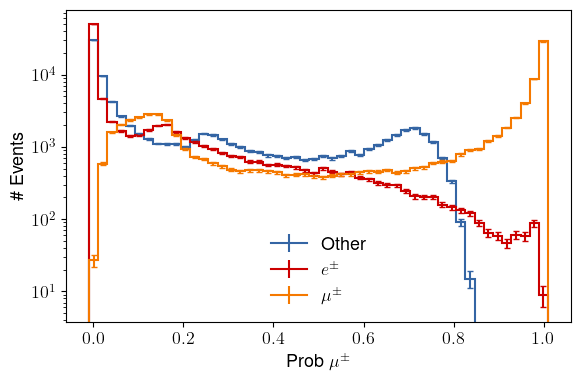

In [20]:
plot_probabilities(
    y_true=y_true,
    y_prob=y_prob,
    class_names=[hit.latex_name for hit in hits],
    yscale="log",
)